# Week 10: Mobile Robot Kinematics

**ID Student:** 22302421

**Name:** Nguyễn Phúc Minh Châu

In [9]:
#libraries
import numpy as np
import matplotlib.pyplot as plt

## Part A: Unicycle & Diff-Drive kinematics — Simulate trajectories in Python

### Lab 10.1 — Writing unicycle_step

In [1]:
def unicycle_step(x, y, th, v, w, dt):
    x_new = x + v * np.cos(th) * dt
    y_new = y + v * np.sin(th) * dt
    th_new = th + w * dt
    return x_new, y_new, th_new

### Lab 10.2 — Simulating Basic Unicycle Trajectories

#### **Case 1:** Đường thẳng (Straight Line)

- **Cơ sở lý thuyết:** Vì vận tốc góc $w = 0$, góc hướng của robot không đổi: $\theta(t) = \theta_0$. Khi đó, phương trình vi phân tọa độ $x$ trở thành:

$$x(t) = x_0 + \int_{0}^{t} v \cos(\theta_0) dt = x_0 + v t \cos(\theta_0)$$

Đoạn code in ra giá trị thực nghiệm (chạy bằng vòng lặp) và lý thuyết. Hai giá trị này sẽ gần như trùng khớp hoàn toàn (chênh lệch rất nhỏ do sai số xấp xỉ Euler $dt$). Đồ thị xuất ra là một đường thẳng xiên góc $\theta_0$.

Case 1 - Thực nghiệm x(10.0s): 7.0711
Case 1 - Lý thuyết x(10.0s)  : 7.0711


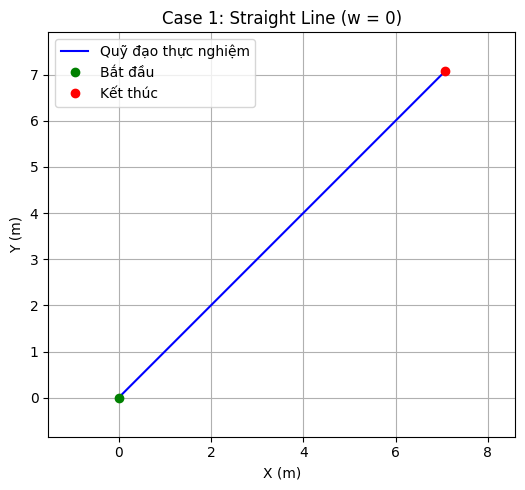

In [8]:
# --- Cấu hình chung cho mô phỏng ---
dt = 0.1       # Bước thời gian (giây)
T = 10.0       # Tổng thời gian mô phỏng (giây)
steps = int(T / dt)

# ==========================================
# CASE 1: Straight Line (Đường thẳng)
# v = const, w = 0
# ==========================================
x1, y1, th1 = 0.0, 0.0, np.pi/4  # Khởi tạo (vị trí gốc, góc th0 = 45 độ)
v1 = 1.0
w1 = 0.0

traj_x1, traj_y1 = [x1], [y1]

for _ in range(steps):
    x1, y1, th1 = unicycle_step(x1, y1, th1, v1, w1, dt)
    traj_x1.append(x1)
    traj_y1.append(y1)

# Kiểm chứng lý thuyết: x(t) = x0 + v * t * cos(th0)
t_final = T
x_analytical = 0.0 + v1 * t_final * np.cos(np.pi/4)
print(f"Case 1 - Thực nghiệm x({t_final}s): {x1:.4f}")
print(f"Case 1 - Lý thuyết x({t_final}s)  : {x_analytical:.4f}")


plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(traj_x1, traj_y1, 'b-', label='Quỹ đạo thực nghiệm')
plt.plot(traj_x1[0], traj_y1[0], 'go', label='Bắt đầu')
plt.plot(traj_x1[-1], traj_y1[-1], 'ro', label='Kết thúc')
plt.title('Case 1: Straight Line (w = 0)')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### **Case 2:** Đường tròn (Circle)

- **Cơ sở lý thuyết:** Khi cả $v$ và $w$ đều là hằng số và $w \neq 0$, robot sẽ quay đều với bán kính quỹ đạo:

$$R = \frac{v}{w}$$

Với cấu hình trong code ($v=2.0, w=0.5$), bán kính tính toán là $R = 4.0$. Đồ thị xuất ra sẽ là một đường tròn hoàn chỉnh (hoặc một cung tròn tùy thuộc vào tổng thời gian $T$ bạn thiết lập). Bạn có thể kiểm tra khoảng cách từ tâm đường tròn đến các điểm trên đồ thị để xác nhận bán kính đúng bằng 4.

Case 2 - Bán kính lý thuyết R = v/w: 4.00


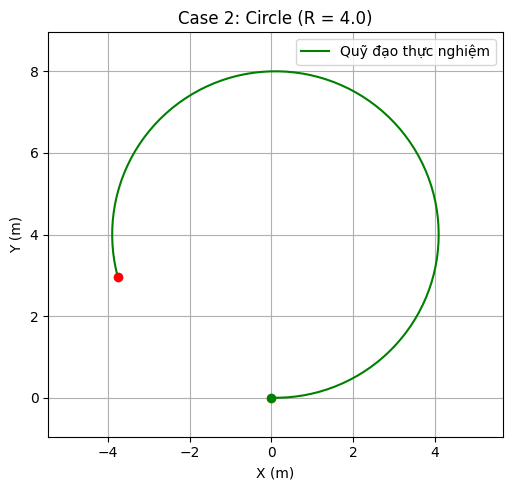

In [3]:
# ==========================================
# CASE 2: Circle (Đường tròn)
# v = const, w = const != 0
# ==========================================
x2, y2, th2 = 0.0, 0.0, 0.0      # Khởi tạo
v2 = 2.0
w2 = 0.5                         # Bán kính lý thuyết R = v/w = 2.0 / 0.5 = 4.0

traj_x2, traj_y2 = [x2], [y2]

for _ in range(steps):
    x2, y2, th2 = unicycle_step(x2, y2, th2, v2, w2, dt)
    traj_x2.append(x2)
    traj_y2.append(y2)

print(f"Case 2 - Bán kính lý thuyết R = v/w: {v2/w2:.2f}")

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 2)
plt.plot(traj_x2, traj_y2, 'g-', label='Quỹ đạo thực nghiệm')
plt.plot(traj_x2[0], traj_y2[0], 'go')
plt.plot(traj_x2[-1], traj_y2[-1], 'ro')
plt.title(f'Case 2: Circle (R = {v2/w2})')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### **Case 3:** Quỹ đạo tự do (Free Trajectory)

- **Cơ chế:** Ở đây chúng ta cho $w(t) = 1.0 \times \sin(t)$. Nghĩa là $w$ sẽ liên tục thay đổi từ dương (rẽ trái) sang âm (rẽ phải).

Đồ thị thu được sẽ là một đường uốn lượn hình sin (slalom path) trông giống như một con rắn đang bò về phía trước. Nếu muốn chuyển thành đường zig-zag, bạn chỉ cần thay hàm sin bằng một hàm bước (step change) thay đổi đột ngột giữa hằng số dương và âm.

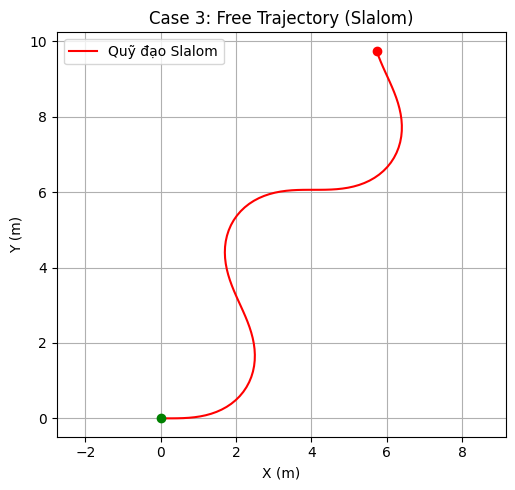

In [4]:
# ==========================================
# CASE 3: Free Trajectory - Slalom (Quỹ đạo hình sin)
# v(t) = const, w(t) thay đổi theo hàm sin
# ==========================================
x3, y3, th3 = 0.0, 0.0, 0.0      # Khởi tạo
v3 = 1.5

traj_x3, traj_y3 = [x3], [y3]

for step in range(steps):
    t = step * dt
    # Tạo w(t) thay đổi hình sin để robot rẽ trái phải liên tục
    w3 = 1.0 * np.sin(t) 
    
    x3, y3, th3 = unicycle_step(x3, y3, th3, v3, w3, dt)
    traj_x3.append(x3)
    traj_y3.append(y3)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 3)
plt.plot(traj_x3, traj_y3, 'r-', label='Quỹ đạo Slalom')
plt.plot(traj_x3[0], traj_y3[0], 'go')
plt.plot(traj_x3[-1], traj_y3[-1], 'ro')
plt.title('Case 3: Free Trajectory (Slalom)')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Lab 10.2 — Simulation Loop Code

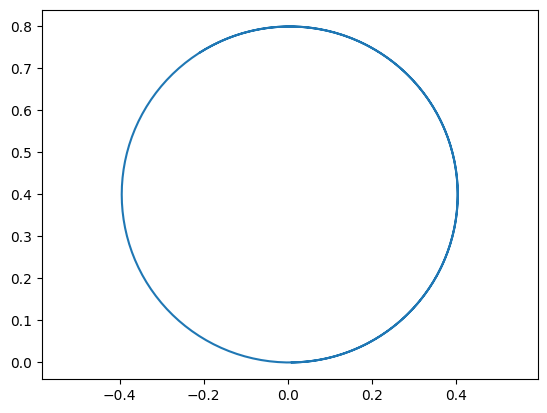

In [5]:
dt = 0.05 # time step (seconds)
steps = 400 # total simulation steps
x, y, th = 0.0, 0.0, 0.0
traj = []
for k in range(steps):
 t = k * dt
 v = 0.2 # try changing this
 w = 0.5 # try 0, 0.5, -0.3, sin(t)
 x, y, th = unicycle_step(x, y, th, v, w, dt)
 traj.append((x, y))
# Plot trajectory
import matplotlib.pyplot as plt
xs, ys = zip(*traj)
plt.plot(xs, ys); plt.axis('equal'); plt.show()

### Lab 10.3 — Implementing diff_drive_step

In [6]:
def diff_drive_step(x, y, th, v_L, v_R, W, dt):
    v = (v_R + v_L) / 2.0
    w = (v_R - v_L) / W
    return unicycle_step(x, y, th, v, w, dt)

### Lab 10.4 — Diff-Drive Trajectory Simulation

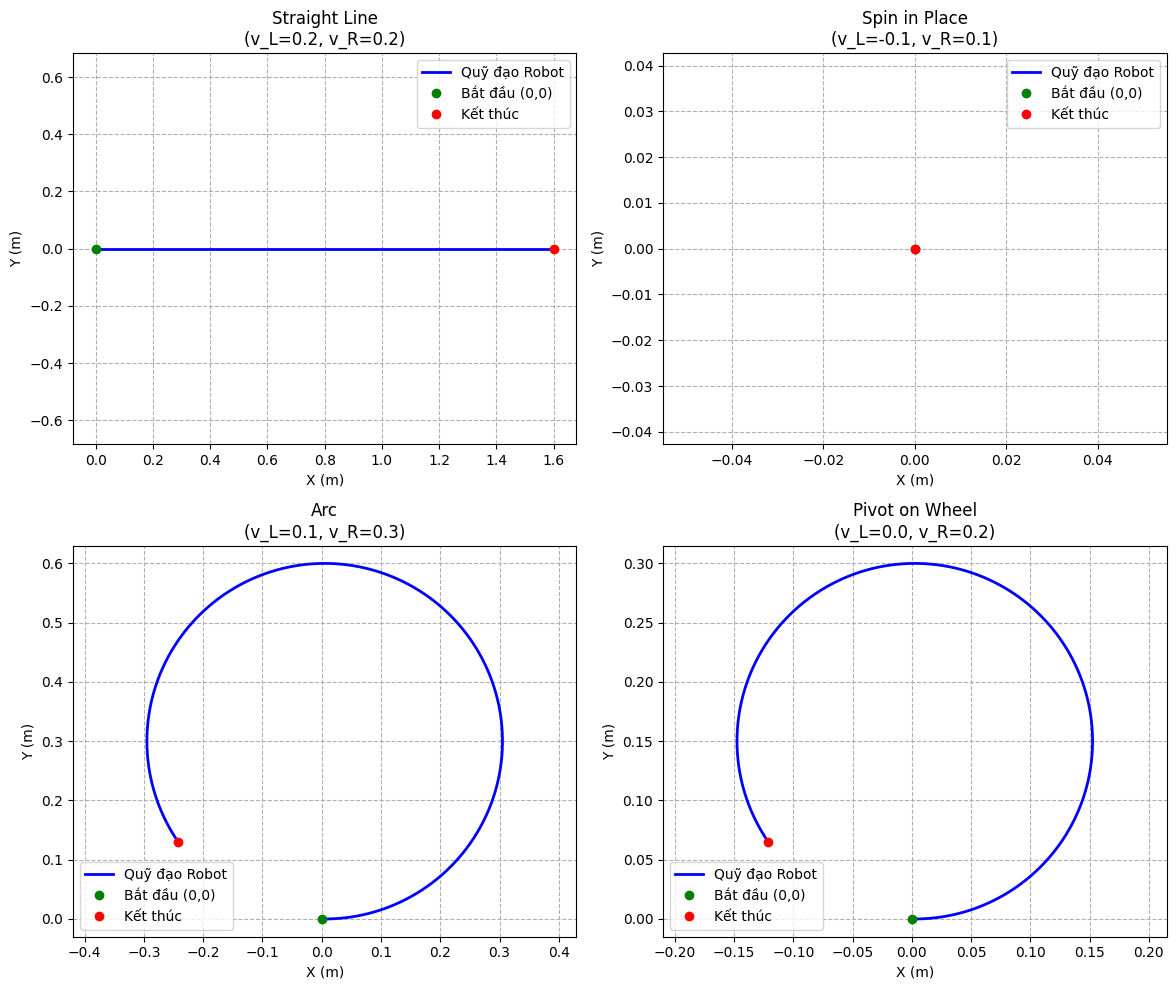

In [7]:
# --- Cấu hình thông số Robot và Mô phỏng ---
W = 0.3        # Khoảng cách giữa 2 bánh xe (mét)
dt = 0.05      # Bước thời gian (giây)
T = 8.0        # Tổng thời gian mô phỏng cho mỗi trường hợp (giây)
steps = int(T / dt)

# Khởi tạo dict để lưu quỹ đạo của từng trường hợp
trajectories = {
    "Straight Line": {"v_L": 0.2, "v_R": 0.2},
    "Spin in Place": {"v_L": -0.1, "v_R": 0.1},
    "Arc":           {"v_L": 0.1, "v_R": 0.3},
    "Pivot on Wheel":{"v_L": 0.0, "v_R": 0.2}
}

results = {}

# --- Chạy vòng lặp mô phỏng cho cả 4 cấu hình ---
for name, conf in trajectories.items():
    # Tất cả các trường hợp đều xuất phát từ gốc tọa độ (0, 0) góc th hướng lên (pi/2) hoặc đi ngang (0)
    # Chọn th0 = 0 (hướng theo trục X) cho dễ quan sát
    x, y, th = 0.0, 0.0, 0.0 
    
    traj_x, traj_y = [x], [y]
    
    for _ in range(steps):
        x, y, th = diff_drive_step(x, y, th, conf["v_L"], conf["v_R"], W, dt)
        traj_x.append(x)
        traj_y.append(y)
        
    results[name] = (traj_x, traj_y)

# --- VẼ ĐỒ THỊ KẾT QUẢ ---
plt.figure(figsize=(12, 10))

plot_idx = 1
for name, (tx, ty) in results.items():
    plt.subplot(2, 2, plot_idx)
    plt.plot(tx, ty, label='Quỹ đạo Robot', color='blue', linewidth=2)
    plt.plot(tx[0], ty[0], 'go', label='Bắt đầu (0,0)')
    plt.plot(tx[-1], ty[-1], 'ro', label='Kết thúc')
    
    # Định dạng đồ thị
    plt.title(f"{name}\n(v_L={trajectories[name]['v_L']}, v_R={trajectories[name]['v_R']})")
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.axis('equal') # Giữ tỉ lệ 1:1 để không bị méo hình tròn/đường cong
    plt.grid(True, linestyle='--')
    plt.legend()
    plot_idx += 1

plt.tight_layout()
plt.show()

1. Straight Line ($v_L = v_R = 0.2$)

    - Unicycle tương đương: $v = 0.2\text{ m/s}$, $\omega = 0\text{ rad/s}$.
    
    - Trực quan: Hai bánh xe quay cùng vận tốc và cùng chiều $\rightarrow$ Robot tịnh tiến thẳng về phía trước dọc theo hướng ban đầu, không bị lệch hướng.

2. Spin in Place ($v_L = -v_R = -0.1$ hoặc $v_L = -0.1, v_R = 0.1$)
    
    - Unicycle tương đương: $v = 0\text{ m/s}$, $\omega = \frac{0.1 - (-0.1)}{0.3} = 0.667\text{ rad/s}$.
    
    - Trực quan: Robot đứng yên tại chỗ ($v=0$) nhưng tự quay quanh tâm trục bánh xe của chính nó. Trên đồ thị, bạn sẽ chỉ thấy một dấu chấm tròn tại gốc (0,0) vì tọa độ $(x,y)$ không thay đổi, chỉ có góc $\theta$ thay đổi liên tục.
    
    Lưu ý: Kiểu di chuyển này xe ô tô thông thường (hệ Ackermann) không làm được, chỉ có xe robot bánh vi sai hoặc bánh xích (xe tăng) mới làm được.

3. Arc ($v_L = 0.1, v_R = 0.3$)
    
    - Unicycle tương đương: $v = 0.2\text{ m/s}$, $\omega = \frac{0.3 - 0.1}{0.3} = 0.667\text{ rad/s}$.
    
    - Trực quan: Bánh bên phải quay nhanh hơn bánh bên trái ($v_R > v_L$) $\rightarrow$ robot rẽ cong về phía bên trái (ngược chiều kim đồng hồ). Quỹ đạo vẽ ra là một cung tròn hoàn hảo với bán kính ICC (Instantaneous Center of Curvature) là $R = \frac{v}{\omega} = \frac{0.2}{0.667} = 0.3\text{ m}$.

4. Pivot on wheel ($v_L = 0, v_R = 0.2$)

    - Unicycle tương đương: $v = 0.1\text{ m/s}$, $\omega = \frac{0.2 - 0}{0.3} = 0.667\text{ rad/s}$.
    
    - Trực quan: Bánh trái đứng yên đóng vai trò làm tâm xoay, bánh phải chủ động quay tròn quanh tâm đó $\rightarrow$ Tạo ra một cú rẽ cực gắt (Tight turn). Bán kính quỹ đạo tính từ tâm robot đến tâm xoay đúng bằng nửa chiều rộng xe: $R = \frac{v}{\omega} = \frac{0.1}{0.667} = 0.15\text{ m} = \frac{W}{2}$.

### Lab 10.5 — Basic Path-Following for Unicycle

<img src="path_following_controller.png">

Ý tưởng thuật toán bám đường (Path-Following): 

- Vận tốc dài $v$: Giữ nguyên là hằng số ($v = 0.2$).

- Vận tốc góc $\omega$: Được tính dựa trên sai số góc hướng $e_\theta$:$$\omega = k \cdot e_\theta$$
    
Cách tìm sai số $e_\theta$:

- Xác định một điểm nhìn trước (look-ahead point) trên đường thẳng tham chiếu dựa theo vị trí $x$ hiện tại của robot.

- Tính góc hướng mong muốn ($\theta_{goal}$) từ robot đến điểm look-ahead đó bằng hàm np.arctan2.

- Sai số góc: $e_\theta = \theta_{goal} - \theta_{current}$. Chúng ta cần chuẩn hóa $e_\theta$ về khoảng $[-\pi, \pi]$ để tránh robot quay vòng luẩn quẩn vô lý.

In [10]:
# --- Định nghĩa đường thẳng tham chiếu ---
# Giả sử đường thẳng cần bám theo là trục hoành Y = 2.0 (Đường thẳng nằm ngang cách gốc 2m)
def get_look_ahead_point(robot_x):
    # Điểm nhìn trước trên đường thẳng luôn đi trước tọa độ x của robot một khoảng (ví dụ 0.5m)
    look_ahead_x = robot_x + 0.5
    look_ahead_y = 2.0
    return look_ahead_x, look_ahead_y


# --- Hàm chạy mô phỏng bám đường với hệ số k tùy chọn ---
def simulate_path_following(k_gain):
    # Khởi tạo vị trí ban đầu của robot (Lệch khỏi đường thẳng tham chiếu)
    # Robot xuất phát ở (0, 0) và hướng nhìn nằm ngang (0 rad), đường thẳng ở Y = 2.0
    x, y, th = 0.0, 0.0, 0.0
    
    v = 0.2        # Vận tốc dài cố định theo yêu cầu đề bài
    dt = 0.1       # Bước thời gian
    T = 25.0       # Thời gian mô phỏng (giây)
    steps = int(T / dt)
    
    traj_x, traj_y = [x], [y]
    
    for _ in range(steps):
        # 1. Tìm điểm mục tiêu nhìn trước (Look-ahead)
        gx, gy = get_look_ahead_point(x)
        
        # 2. Tính góc hướng mong muốn để đi tới điểm nhìn trước
        th_goal = np.arctan2(gy - y, gx - x)
        
        # 3. Tính sai số góc e_theta và chuẩn hóa về [-pi, pi]
        e_th = th_goal - th
        e_th = np.arctan2(np.sin(e_th), np.cos(e_th))
        
        # 4. Bộ điều khiển tỷ lệ (Proportional Controller)
        w = k_gain * e_th
        
        # 5. Cập nhật trạng thái robot
        x, y, th = unicycle_step(x, y, th, v, w, dt)
        
        traj_x.append(x)
        traj_y.append(y)
        
    return traj_x, traj_y

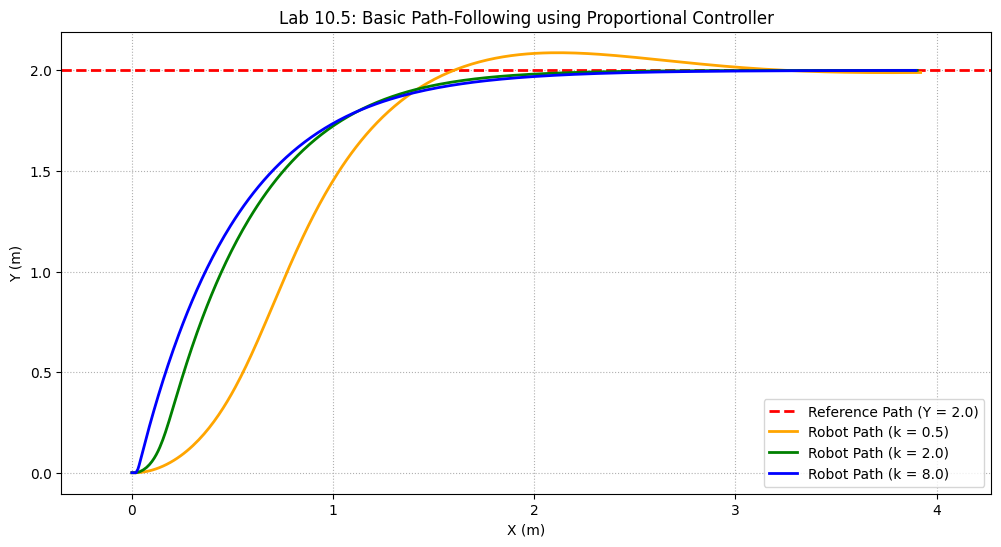

In [11]:
# --- Thử nghiệm với các giá trị k khác nhau để quan sát ---
k_values = [0.5, 2.0, 8.0] # K nhỏ, K vừa vặn, K quá lớn gây dao động
results = {}

for k in k_values:
    results[k] = simulate_path_following(k)

# --- VẼ ĐỒ THỊ KẾT QUẢ ---
plt.figure(figsize=(12, 6))

# Vẽ đường thẳng tham chiếu (Đường thẳng đích Y = 2)
plt.axhline(y=2.0, color='r', linestyle='--', linewidth=2, label='Reference Path (Y = 2.0)')

# Vẽ quỹ đạo của robot ứng với từng hệ số k
colors = ['orange', 'green', 'blue']
for i, k in enumerate(k_values):
    tx, ty = results[k]
    plt.plot(tx, ty, color=colors[i], label=f'Robot Path (k = {k})', linewidth=2)

# Định dạng đồ thị
plt.title('Lab 10.5: Basic Path-Following using Proportional Controller')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.ylim(-0.5, 3.0)
plt.grid(True, linestyle=':')
plt.legend()
plt.axis('equal')
plt.show()

## Part B: Ackermann & Jet Racer — simulate car-like trajectories with SDK mapping

### Lab 10.B1 — Writing ackermann_step

In [12]:
def ackermann_step(x, y, th, v, delta, L, dt):
    x_new = x + v * np.cos(th) * dt
    y_new = y + v * np.sin(th) * dt
    th_new = th + (v / L) * np.tan(delta) * dt
    return x_new, y_new, th_new

### Lab 10.B2 — Simulating Jet Racer Trajectories

**Case 1 Straight Line ($\delta = 0$):** 

Khi bánh lái thẳng đứng, vận tốc góc bằng không ($\omega = 0$). Xe chuyển động tịnh tiến thẳng giống hệt như mô hình Unicycle có $\omega = 0$.

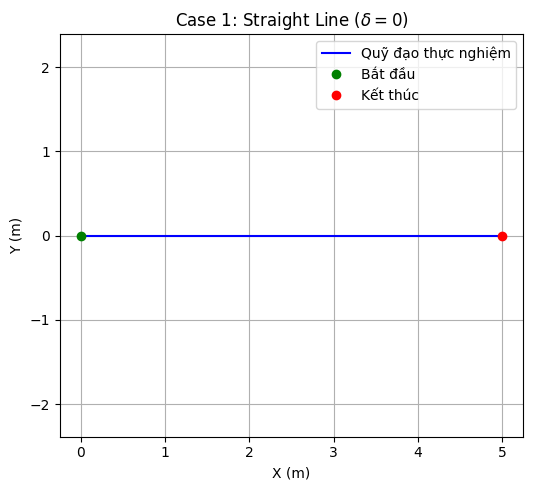

In [18]:
# --- Cấu hình thông số xe và mô phỏng ---
L = 0.2         # Chiều dài cơ sở của xe JetRacer (ví dụ: 0.2 mét hoặc 20cm)
dt = 0.05       # Bước thời gian (giây)
T = 10.0        # Tổng thời gian mô phỏng (giây)
steps = int(T / dt)

# ==========================================
# CASE 1: Straight Line (Đường thẳng)
# delta = 0 -> w = 0
# ==========================================
x1, y1, th1 = 0.0, 0.0, 0.0  # Khởi tạo vị trí gốc
v1 = 0.5                     # Vận tốc 0.5 m/s
delta1 = 0.0                 # Góc lái bằng 0

traj_x1, traj_y1 = [x1], [y1]

for _ in range(steps):
    x1, y1, th1 = ackermann_step(x1, y1, th1, v1, delta1, L, dt)
    traj_x1.append(x1)
    traj_y1.append(y1)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(traj_x1, traj_y1, 'b-', label='Quỹ đạo thực nghiệm')
plt.plot(traj_x1[0], traj_y1[0], 'go', label='Bắt đầu')
plt.plot(traj_x1[-1], traj_y1[-1], 'ro', label='Kết thúc')
plt.title('Case 1: Straight Line ($\\delta = 0$)')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

**Case 2 Constant Circle ($\delta = \text{const}$):** 

Khi giữ nguyên góc lái, xe chuyển động tròn đều với bán kính $R = \frac{L}{\tan\delta}$. Kết quả này tương đương với mô hình Unicycle có $\omega = \frac{v}{R} = \frac{v \cdot \tan\delta}{L}$.

Case 2 - Bán kính lý thuyết R = L/tan(delta): 0.7464 m


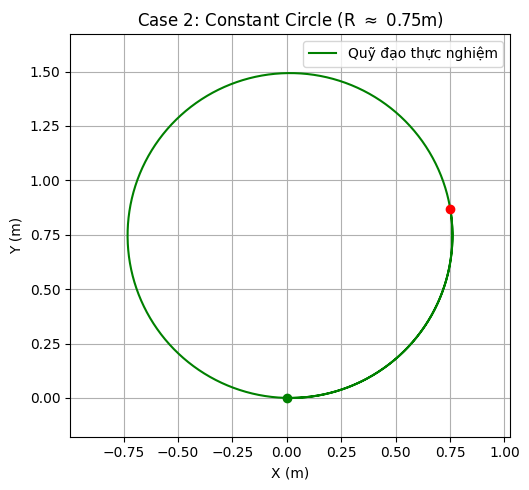

In [14]:
# ==========================================
# CASE 2: Constant Circle (Đường tròn hằng số)
# delta = const != 0 -> bán kính lý thuyết R = L / tan(delta)
# ==========================================
x2, y2, th2 = 0.0, 0.0, 0.0
v2 = 0.6
delta2 = np.radians(15)      # Góc lái cố định 15 độ

traj_x2, traj_y2 = [x2], [y2]

for _ in range(steps):
    x2, y2, th2 = ackermann_step(x2, y2, th2, v2, delta2, L, dt)
    traj_x2.append(x2)
    traj_y2.append(y2)

# Tính bán kính đường tròn lý thuyết để đối chiếu
R_analytical = L / np.tan(delta2)
print(f"Case 2 - Bán kính lý thuyết R = L/tan(delta): {R_analytical:.4f} m")

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 2)
plt.plot(traj_x2, traj_y2, 'g-', label='Quỹ đạo thực nghiệm')
plt.plot(traj_x2[0], traj_y2[0], 'go')
plt.plot(traj_x2[-1], traj_y2[-1], 'ro')
plt.title(f'Case 2: Constant Circle (R $\\approx$ {R_analytical:.2f}m)')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

**Case 3 Slalom:** 

Việc lắc vô lăng (thay đổi góc $\delta$) qua lại theo hàm sin tạo ra quỹ đạo hình chữ S đối xứng rất mượt mà.

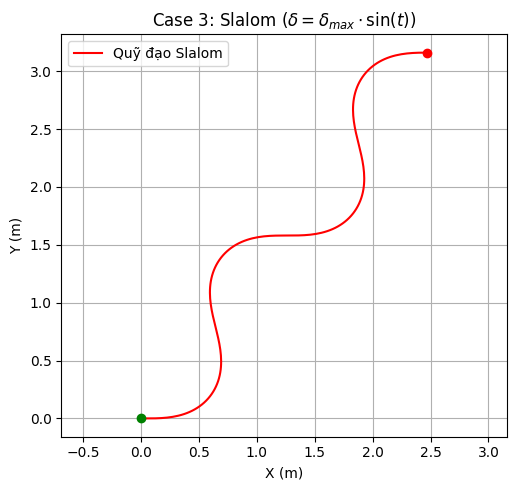

In [17]:
# ==========================================
# CASE 3: Slalom (Quỹ đạo uốn lượn hình chữ S)
# delta(t) thay đổi liên tục theo hàm sin
# ==========================================
x3, y3, th3 = 0.0, 0.0, 0.0
v3 = 0.5
delta_max = np.radians(25)   # Biên độ góc lái lớn nhất là 25 độ

traj_x3, traj_y3 = [x3], [y3]

for step in range(steps):
    t = step * dt
    # Góc lái delta dao động hình sin theo thời gian
    delta3 = delta_max * np.sin(2 * np.pi * 0.2 * t) # Tần số 0.2 Hz
    
    x3, y3, th3 = ackermann_step(x3, y3, th3, v3, delta3, L, dt)
    traj_x3.append(x3)
    traj_y3.append(y3)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 3)
plt.plot(traj_x3, traj_y3, 'r-', label='Quỹ đạo Slalom')
plt.plot(traj_x3[0], traj_y3[0], 'go')
plt.plot(traj_x3[-1], traj_y3[-1], 'ro')
plt.title('Case 3: Slalom ($\\delta = \\delta_{max} \\cdot \\sin(t)$)')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Không giống như mô hình bánh vi sai (Diff-drive) ở Lab 10.4, mô hình Ackermann không thể xoay tại chỗ (Spin in place).

Bởi vì góc lái của bánh trước luôn bị giới hạn bởi một góc tối đa $\delta_{max}$, xe Ackermann luôn có một bán kính quay vòng tối thiểu (Minimum turning radius):

$$R_{min} = \frac{L}{\tan(\delta_{max})}$$

Nếu muốn quay đầu, xe bắt buộc phải di chuyển tiến/lùi tạo thành một vòng vòng cung rộng chứ không thể đứng yên một chỗ để xoay.

### Lab 10.B3 — Wrapping SDK Commands into Ackermann Simulation

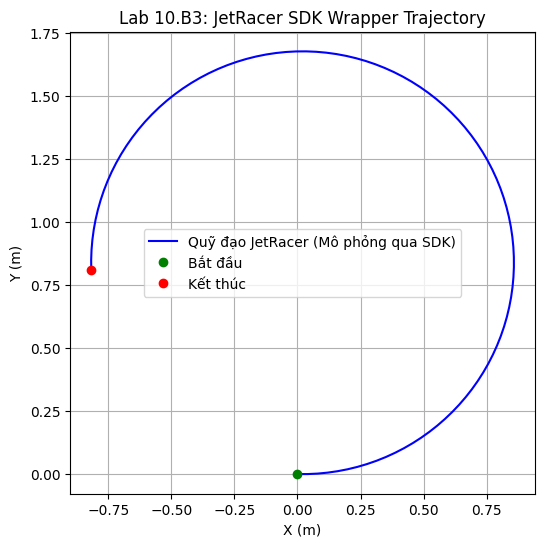

In [20]:
V_MAX = 1.0 # m/s
DELTA_MAX = 0.5 # rad (~28 degrees)
L = 0.17 # wheelbase in meters

def jet_racer_step(x, y, th, steering, throttle, dt):
    v = throttle * V_MAX
    delta = steering * DELTA_MAX
    return ackermann_step(x, y, th, v, delta, L, dt)

dt = 0.05
T = 5.0  # Chạy trong 5 giây
steps = int(T / dt)

x, y, th = 0.0, 0.0, 0.0  # Trạng thái ban đầu
traj_x, traj_y = [x], [y]

for _ in range(steps):
    # Gửi lệnh dạng SDK thay vì truyền trực tiếp v và delta
    x, y, th = jet_racer_step(x, y, th, steering=0.4, throttle=0.8, dt=dt)
    traj_x.append(x)
    traj_y.append(y)

plt.figure(figsize=(6, 6))
plt.plot(traj_x, traj_y, 'b-', label='Quỹ đạo JetRacer (Mô phỏng qua SDK)')
plt.plot(traj_x[0], traj_y[0], 'go', label='Bắt đầu')
plt.plot(traj_x[-1], traj_y[-1], 'ro', label='Kết thúc')
plt.title('Lab 10.B3: JetRacer SDK Wrapper Trajectory')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()